# parts associated with developing graupel model

In [1]:
import sys
import math
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset # !! new - building netcdf
import os # file saving 
import xarray as xr


### blerg - ignore

In [27]:
save_loc = "./model_output/" # location to save output files
os.makedirs(save_loc, exist_ok=True) # if make folder, if already exist, do nothing
save_name = 'test_output'

'''
diam = np.array([.05, .1, .15, .2, .3, .4,
                  .5, .6, .7, .8, .9, 1., 1.1, 1.2,
                  1.4, 1.6, 1.8, 2.0, 2.2, 2.4]) ## i assume initial particle diameters (mm) ??


MAX1 = len(diam)   # number of particle size categories
MAX3 = 9000        # number of time steps
MAX4 = 24          # number of grid points in vertical

DBAR = 20 # 
RATTH = 0.1 # ratio of LWC ?
RATCT = 0.1 #
RATDEB = 0.05
RATDOWN = 0.05
WCTDEB = -3. # debris collapse speed (m/s) ??
CTOP = 8. # cloud top (km)
TDEPTH = 2. # thermal depth (km)
TGAP = 1. # gap between thermals - bottom of thermal 1 and top of thermal 2 (km) ?
TWID = 2. # thermal width (km) ? 
DOWN = 0.4
UMAX = 2. # max updraft (m/s) ??
ZCT = TDEPTH / 6. # ratio of thermal top / depth of thermal 
ZCT1 = ZCT / 3.
ZCT2 = 2. * ZCT / 3.

P0 = 1013. # surface (sea level) pressure (mb)
T0 = 288. # surface temperature (K)
GAMMA = 0.0065 # constant lapse rate (ºC/m)
RHOI = 920 # density of ice (kg/m^3)
EPS = 0.622 # constant for water vapour calculation
PI = 3.14159 # constant pi 
RD = 287.05 # gas constant for dry air (J/kg/K)
RV = 461.51 # gas constant for water vapor (J/kg/K)
TK = 2.32e-2 # thermal conductivity of air (W/m/K) ??
D = 2.11e-5 # molecular diffusivity of water vapor in air (m^2/s) ??
TTR = 273.16 # triple point temperature of water (K) ??
RW = 461.51 # gas constant for water vapor (J/kg/K)
LS = 2.837e6 # latent heat of sublimation (J/kg)
LF = 3.12e5 # latent heat of fusion (J/kg)
LV = 2.5e6 # latent heat of vaporization (J/kg)
NMAX = 500.e6 # 
DIS = 0.25 # dispersion 
GRAV = 9.81 # gravity
ETA = 1.67e-5 # dynamic viscosity of air (Pa*s) ?
CPW = 4.27e3 # specific heat of water (J/kg/K)
'''

MAX2 = 1500        # number of altitude values 
DELTIM = 5. # time step interval (s)
runtime = 60
numt = int(runtime * 60. / DELTIM)
time = np.zeros(numt)
time[:] = np.arange(numt) * DELTIM
alt = np.zeros(MAX2)
for ii in range(MAX2):
    # create atmosphere environment at every height
    # then at each level, define atmospheric properties
    alt[ii] = 10. * ii # each level seperated by 10 m


In [ ]:
#alt
time#.dtype

dtype('float64')

In [35]:
fname = os.path.join(save_loc, f"{save_name}.nc")
nc = Dataset(fname, "w", format="NETCDF4")
# dimensions - - - - - -
nc.createDimension("time", len(time))
nc.createDimension("height", len(alt))
# variables - - - - - -
time_var = nc.createVariable("time", "f4", ("time",))
time_var.units = f"seconds since simulation start (dt={DELTIM}s)"
time_var.long_name = "simulation time"
time_var[:] = time
height_var = nc.createVariable("height", "f4", ("height",))
height_var.units = "m"
height_var.long_name = "height above ground"
height_var[:] = alt
nc.close()

In [14]:
time_var

RuntimeError: NetCDF: Not a valid ID

### open existing nc file

In [2]:
## try and open netcdf that has been created
# save_name
save_loc = "./model_output/" # location to save output files
save_name = 'test_output'
ncfile = xr.open_dataset(f"{save_loc}{save_name}.nc", decode_times=False)
ncfile_envi = xr.open_dataset(f"{save_loc}{save_name}.nc", group="environment", engine="netcdf4",decode_times=False)
ncfile_ice = xr.open_dataset(f"{save_loc}{save_name}.nc", group="ice_particles", engine="netcdf4",decode_times=False)

In [3]:
ncfile

<xarray.Dataset> Size: 9kB
Dimensions:   (time: 720, height: 1500, particle: 20)
Coordinates:
  * time      (time) float32 3kB 0.0 5.0 10.0 ... 3.585e+03 3.59e+03 3.595e+03
  * height    (height) float32 6kB 0.0 10.0 20.0 ... 1.498e+04 1.499e+04
  * particle  (particle) int32 80B 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 2 2 2
Data variables:
    *empty*

In [4]:
ncfile_envi

<xarray.Dataset> Size: 47kB
Dimensions:              (height: 1500, time: 720)
Dimensions without coordinates: height, time
Data variables:
    pressure             (height) float32 6kB ...
    temperature          (height) float32 6kB ...
    lwc                  (height) float32 6kB ...
    cloud_drop_diameter  (height) float32 6kB ...
    vertical_velocity    (height) float32 6kB ...
    thermal_top_1        (time) float32 3kB ...
    thermal_base_1       (time) float32 3kB ...
    thermal_top_2        (time) float32 3kB ...
    thermal_base_2       (time) float32 3kB ...
    cloud_top            (time) float32 3kB ...
    debris_base          (time) float32 3kB ...

In [5]:
ncfile_ice

<xarray.Dataset> Size: 403kB
Dimensions:              (particle: 20, time: 720)
Dimensions without coordinates: particle, time
Data variables:
    diameter             (particle, time) float32 58kB ...
    density              (particle, time) float32 58kB ...
    mass                 (particle, time) float32 58kB ...
    surface_temperature  (particle, time) float32 58kB ...
    terminal_velocity    (particle, time) float32 58kB ...
    altitude             (particle, time) float32 58kB ...
    horizontal_position  (particle, time) float32 58kB ...

#### temp profile ✅

(0.0, 20.0)

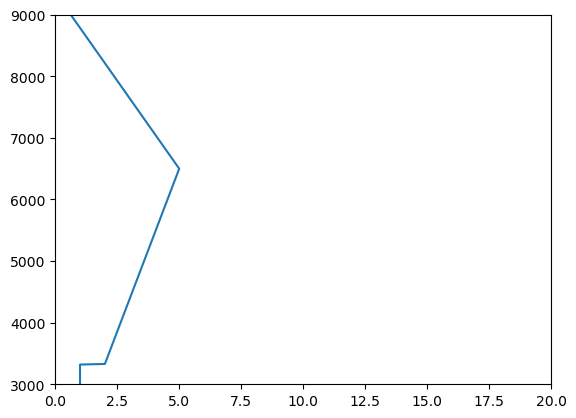

In [6]:
#ncfile_envi['temperature'].plot()
plt.plot(ncfile_envi['vertical_velocity'].values, ncfile['height'].values)
plt.ylim(3000,9000)
plt.xlim(0,20)

#### particle trajectory

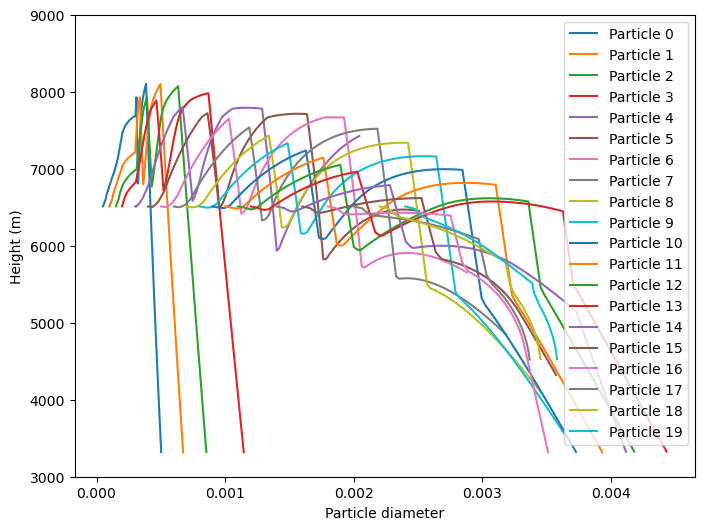

In [7]:

fig, ax = plt.subplots(figsize=(8, 6))

for p in range(ncfile_ice.sizes["particle"]):

    altitude = ncfile_ice["altitude"].isel(particle=p).values
    diameter = ncfile_ice["diameter"].isel(particle=p).values

    ax.plot(
        diameter,
        altitude,
        linewidth=1.5,
        label=f"Particle {p}"
    )

ax.set_xlabel("Particle diameter")
ax.set_ylabel("Height (m)")
ax.set_ylim(3000, 9000)

plt.legend()
plt.show()

In [8]:
#print(ncfile_ice["altitude"])
#print(ncfile_ice["diameter"])

alt = ncfile_ice["altitude"].values
diam = ncfile_ice["diameter"].values

print("altitude shape:", alt.shape)
print("diameter shape:", diam.shape)

print("altitude min/max:", np.nanmin(alt), np.nanmax(alt))
print("diameter min/max:", np.nanmin(diam), np.nanmax(diam))

print("altitude NaNs:", np.isnan(alt).sum(), "/", alt.size)
print("diameter NaNs:", np.isnan(diam).sum(), "/", diam.size)

altitude shape: (20, 720)
diameter shape: (20, 720)
altitude min/max: 3316.7288 8102.5684
diameter min/max: 5e-05 0.004432726
altitude NaNs: 3074 / 14400
diameter NaNs: 3074 / 14400


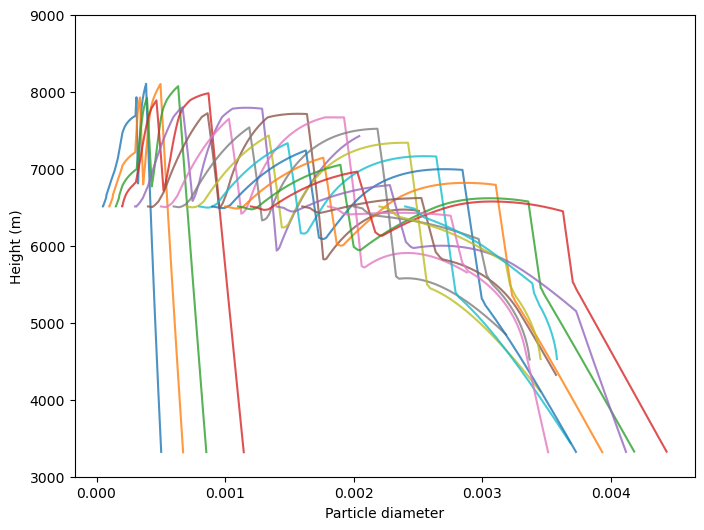

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

for p in range(ncfile_ice.sizes["particle"]):

    altitude = ncfile_ice["altitude"].isel(particle=p).values
    diameter = ncfile_ice["diameter"].isel(particle=p).values

    ax.plot(
        diameter,
        altitude,
        linewidth=1.5,
        alpha=0.8
    )

ax.set_xlabel("Particle diameter")
ax.set_ylabel("Height (m)")
ax.set_ylim(3000, 9000)

plt.show()